# Importing data 8

In [72]:
# read final_mock_dataset.csv into df 
import pandas as pd
df = pd.read_csv('../../data/processed/final_mock_dataset.csv')

# keep only rows where source is 'smart_campus_room_measurements'
df = df[df['source'] == 'smart_campus_room_measurements']
df

,timestamp,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
775247,2025-09-15 00:00:03,smart_campus_room_measurements__room_2_12__s00001,room_2_12,smart_campus_room_measurements:row_00000001,smart_campus_room_measurements,3481.0,3.596096,24.4,6.164414,0.002421,NaN
775249,2025-09-15 00:05:05,smart_campus_room_measurements__room_2_12__s00001,room_2_12,smart_campus_room_measurements:row_00000002,smart_campus_room_measurements,3481.0,3.376347,24.5,6.244998,0.002392,NaN
775251,2025-09-15 00:10:08,smart_campus_room_measurements__room_2_12__s00001,room_2_12,smart_campus_room_measurements:row_00000003,smart_campus_room_measurements,3481.0,3.709738,24.4,6.244998,0.002375,NaN
775253,2025-09-15 00:15:11,smart_campus_room_measurements__room_2_12__s00001,room_2_12,smart_campus_room_measurements:row_00000004,smart_campus_room_measurements,3481.0,3.126553,24.4,6.164414,0.002421,NaN
775255,2025-09-15 00:20:14,smart_campus_room_measurements__room_2_12__s00001,room_2_12,smart_campus_room_measurements:row_00000005,smart_campus_room_measurements,3481.0,4.085742,24.4,6.164414,0.002421,NaN
...,...,...,...,...,...,...,...,...,...,...,...
910477,2025-12-19 23:54:06,smart_campus_room_measurements__room_2_12__s00001,room_2_12,smart_campus_room_measurements:row_00108937,smart_campus_room_measurements,1936.0,3.634130,21.9,7.615773,0.001965,NaN
910479,2025-12-19 23:55:37,smart_campus_room_measurements__lab_2_2__s00001,lab_2_2,smart_campus_room_measurements:row_00108938,smart_campus_room_measurements,2704.0,5.566817,18.4,7.000000,0.001845,NaN
910480,2025-12-19 23:58:37,smart_campus_room_measurements__room_2_5__s00001,room_2_5,smart_campus_room_measurements:row_00108939,smart_campus_room_measurements,2116.0,2.416229,21.5,7.071068,0.001650,NaN
910481,2025-12-19 23:59:04,smart_campus_room_measurements__lab_4_2__s00001,lab_4_2,smart_campus_room_measurements:row_00108940,smart_campus_room_measurements,2116.0,2.718717,21.1,7.071068,0.001754,NaN


## Connecting data 8 of measurements with comfort score ratings
(Data 8 measurements with imputed light is used)

In [73]:
# load comfort perceptions
comfort = pd.read_csv('../../data/raw/DATA_8/smart-campus-comfort-data/4_comfort_perception.csv')

# make sure timestamp is a normal column
if 'timestamp' not in df.columns and df.index.name == 'timestamp':
    df = df.reset_index()

# column names
df_ts_col = 'timestamp'
df_room_col = 'location_id'
comfort_ts_col = 'timestamp'
comfort_room_col = 'room'

# room mapping for the 4 known rooms
df_room_map = {
    'lab_2_2': 'lab_2_2',
    'lab_4_2': 'lab_4_2',
    'room_2_5': 'room_2_5',
    'room_2_12': 'room_2_12',
}
comfort_room_map = {
    'Lab 2.2': 'lab_2_2',
    'Lab 4.2': 'lab_4_2',
    'Room 2.5': 'room_2_5',
    'Room 2.12': 'room_2_12',
}

# parse timestamps
df = df.copy()
df[df_ts_col] = pd.to_datetime(df[df_ts_col], utc=True, errors='coerce')
comfort[comfort_ts_col] = pd.to_datetime(comfort[comfort_ts_col], utc=True, errors='coerce')

# build room key
df['room_key'] = df[df_room_col].map(df_room_map)
comfort['room_key'] = comfort[comfort_room_col].map(comfort_room_map)

# clean and sort
measurements = df.dropna(subset=[df_ts_col, 'room_key']).sort_values(df_ts_col)
comfort_clean = comfort.dropna(subset=[comfort_ts_col, 'room_key']).sort_values(comfort_ts_col)

# merge closest measurement for each rating within 10 minutes
max_gap = pd.Timedelta('4min')
df_with_comfort = pd.merge_asof(
    comfort_clean,
    measurements,
    left_on=comfort_ts_col,
    right_on=df_ts_col,
    by='room_key',
    direction='nearest',
    tolerance=max_gap,
    suffixes=('', '_meas'),
)

# keep only rows that got a measurement
df_with_comfort = df_with_comfort[df_with_comfort[df_room_col].notna()].copy()

# count and export
remaining_rows = len(df_with_comfort)
df_with_comfort.to_csv('../../data/processed/instant_mock.csv', index=False)
remaining_rows

1812

In [74]:
# import data
import pandas as pd
df = pd.read_csv('../../data/processed/instant_mock.csv')
df

,timestamp,respondentId,room,comfortValue,comfortLabel,temperatureValue,temperatureLabel,humidityValue,humidityLabel,airQualityValue,...,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
0,2025-09-17 13:37:11+00:00,13,Lab 4.2,4,Good,0,Optimal,0,Optimal,1,...,smart_campus_room_measurements__lab_4_2__s00001,lab_4_2,smart_campus_room_measurements:row_00002492,smart_campus_room_measurements,4225.0,7.669843,25.1,7.810250,0.001916,NaN
1,2025-09-17 13:37:50+00:00,31,Lab 4.2,5,Excellent,0,Optimal,0,Optimal,0,...,smart_campus_room_measurements__lab_4_2__s00001,lab_4_2,smart_campus_room_measurements:row_00002492,smart_campus_room_measurements,4225.0,7.669843,25.1,7.810250,0.001916,NaN
2,2025-09-17 13:44:41+00:00,3,Lab 4.2,3,Acceptable,0,Optimal,1,Slightly humid,1,...,smart_campus_room_measurements__lab_4_2__s00001,lab_4_2,smart_campus_room_measurements:row_00002501,smart_campus_room_measurements,4096.0,6.835845,25.2,7.810250,0.001976,NaN
3,2025-09-17 13:46:32+00:00,7,Lab 4.2,4,Good,0,Optimal,0,Optimal,0,...,smart_campus_room_measurements__lab_4_2__s00001,lab_4_2,smart_campus_room_measurements:row_00002501,smart_campus_room_measurements,4096.0,6.835845,25.2,7.810250,0.001976,NaN
4,2025-09-17 14:09:50+00:00,26,Lab 4.2,4,Good,0,Optimal,0,Optimal,0,...,smart_campus_room_measurements__lab_4_2__s00001,lab_4_2,smart_campus_room_measurements:row_00002522,smart_campus_room_measurements,3969.0,7.039566,25.3,7.745967,0.001938,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807,2025-12-12 15:22:04+00:00,16,Room 2.5,3,Acceptable,-1,Cool,0,Optimal,0,...,smart_campus_room_measurements__room_2_5__s00001,room_2_5,smart_campus_room_measurements:row_00100701,smart_campus_room_measurements,1764.0,2.156565,21.3,7.937254,0.001250,NaN
1808,2025-12-12 19:26:55+00:00,53,Room 2.5,3,Acceptable,0,Optimal,0,Optimal,0,...,smart_campus_room_measurements__room_2_5__s00001,room_2_5,smart_campus_room_measurements:row_00100889,smart_campus_room_measurements,1681.0,5.996998,20.5,7.000000,0.001572,NaN
1809,2025-12-17 15:42:44+00:00,24,Lab 4.2,3,Acceptable,1,Warm,1,Slightly humid,1,...,smart_campus_room_measurements__lab_4_2__s00001,lab_4_2,smart_campus_room_measurements:row_00106317,smart_campus_room_measurements,2025.0,0.000000,21.1,7.000000,0.001695,NaN
1810,2025-12-17 16:16:11+00:00,28,Lab 4.2,3,Acceptable,-1,Cool,0,Optimal,0,...,smart_campus_room_measurements__lab_4_2__s00001,lab_4_2,smart_campus_room_measurements:row_00106344,smart_campus_room_measurements,2025.0,0.000000,21.1,7.000000,0.001661,NaN


# Analysing and preprocessing data

### Missing values

In [75]:
# drop columns
df = df.drop(columns=[
    'respondentId', 'room', 'comfortLabel', 'temperatureValue', 'temperatureLabel',
    'humidityValue', 'humidityLabel', 'airQualityValue',
    'airQualityLabel', 'noiseValue', 'noiseLabel', 'degreesValue', 'degreesLabel',
    'between', 'and', 'room_key', 'session_id', 'location_id', 'record_id', 'source',
    'focus_score', 'timestamp'
])

df

,comfortValue,humidity,light,temperature,noise,co2
0,4,4225.0,7.669843,25.1,7.810250,0.001916
1,5,4225.0,7.669843,25.1,7.810250,0.001916
2,3,4096.0,6.835845,25.2,7.810250,0.001976
3,4,4096.0,6.835845,25.2,7.810250,0.001976
4,4,3969.0,7.039566,25.3,7.745967,0.001938
...,...,...,...,...,...,...
1807,3,1764.0,2.156565,21.3,7.937254,0.001250
1808,3,1681.0,5.996998,20.5,7.000000,0.001572
1809,3,2025.0,0.000000,21.1,7.000000,0.001695
1810,3,2025.0,0.000000,21.1,7.000000,0.001661


In [76]:
#count missing values
df.isna().sum()

comfortValue    0
humidity        0
light           0
temperature     0
noise           0
co2             0
dtype: int64

<Axes: >

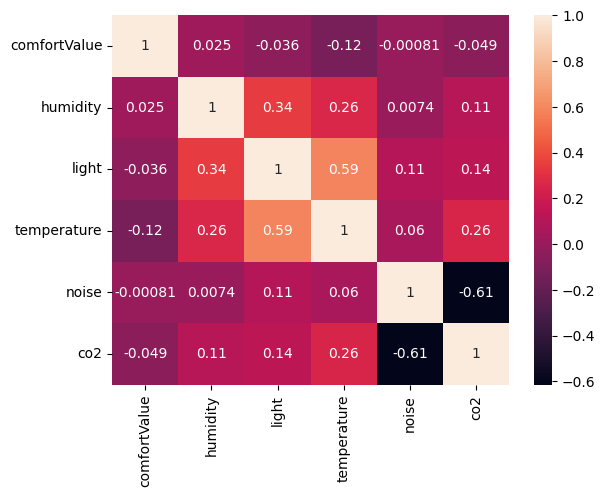

In [78]:
# create correlation matrix in plt
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.corr(), annot=True)

The data was already preprocessed inside the 3_unified_dataset_analysis.ipynb